In [2]:
import pandas as pd
import numpy as np
from sklearn.datasets import load_digits

In [3]:
digits = load_digits()

In [4]:
from sklearn import svm
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.naive_bayes import MultinomialNB
from sklearn.tree import DecisionTreeClassifier

In [5]:
model_params = {
    'svm' : {
        'model': svm.SVC(),
        'params': {
            'C': [0.1, 1, 10, 100],
            'kernel':['linear','rbf','poly'],
            'gamma':['scale','auto',0.1,0.001],
            'degree':[2,3,4]
            
        }
    },
    'Random Forest':{
        'model': RandomForestClassifier(),
        'params':{
            'n_estimators':[50,100,200],
            'criterion': ['gini', 'entropy'],
            'max_depth': [None, 5, 10, 20],
            'min_samples_split': [2, 5, 10],
            'min_samples_leaf': [1, 2, 4]
        }
    },
    'Linear Model': {
        'model': LogisticRegression(),
        'params': {
            'C': [0.01, 0.1, 1, 10, 100],
            'penalty': ['l1', 'l2'],
            'solver': ['liblinear', 'saga'],
            'max_iter': [100, 500, 1000]

        }
    },
    'GaussianNB': {
        'model': GaussianNB(),
        'params':{
            'var_smoothing': [1e-9, 1e-8, 1e-7, 1e-6]
        }
    },
    'MultinomialNB':{
        'model': MultinomialNB(),
        'params': {
            'alpha': [0.1, 0.5, 1.0, 2.0],
            'fit_prior': [True, False]
        }
    },
    'Decision Tree':{
        'model' : DecisionTreeClassifier(),
        'params' : {
            'criterion': ['gini', 'entropy'],
            'splitter': ['best', 'random'],
            'max_depth': [None, 5, 10, 20],
            'min_samples_split': [2, 5, 10],
            'min_samples_leaf': [1, 2, 4]
        }
    }
}

In [6]:
from sklearn.model_selection import GridSearchCV

In [7]:
score = []
for model_name,mp in model_params.items():
    clf= GridSearchCV(mp['model'],mp['params'],cv=5,return_train_score=False,verbose=3,n_jobs=-1)
    clf.fit(digits.data,digits.target)
    score.append({
        'model': model_name,
        'best_score' : clf.best_score_,
        'best_params' : clf.best_params_
    })

Fitting 5 folds for each of 144 candidates, totalling 720 fits
Fitting 5 folds for each of 216 candidates, totalling 1080 fits
Fitting 5 folds for each of 60 candidates, totalling 300 fits


c:\Users\Sohanur Rahman\AppData\Local\Python\pythoncore-3.10-64\lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


Fitting 5 folds for each of 4 candidates, totalling 20 fits
Fitting 5 folds for each of 8 candidates, totalling 40 fits
Fitting 5 folds for each of 144 candidates, totalling 720 fits


In [8]:
df = pd.DataFrame(score,columns=['model','best_score','best_params'])
df

,model,best_score,best_params
0,svm,0.973850,"{'C': 10, 'degree': 2, 'gamma': 'scale', 'kern..."
1,Random Forest,0.941032,"{'criterion': 'gini', 'max_depth': 10, 'min_sa..."
2,Linear Model,0.932685,"{'C': 0.1, 'max_iter': 100, 'penalty': 'l1', '..."
3,GaussianNB,0.838635,{'var_smoothing': 1e-06}
4,MultinomialNB,0.871464,"{'alpha': 2.0, 'fit_prior': True}"
5,Decision Tree,0.813033,"{'criterion': 'entropy', 'max_depth': 20, 'min..."


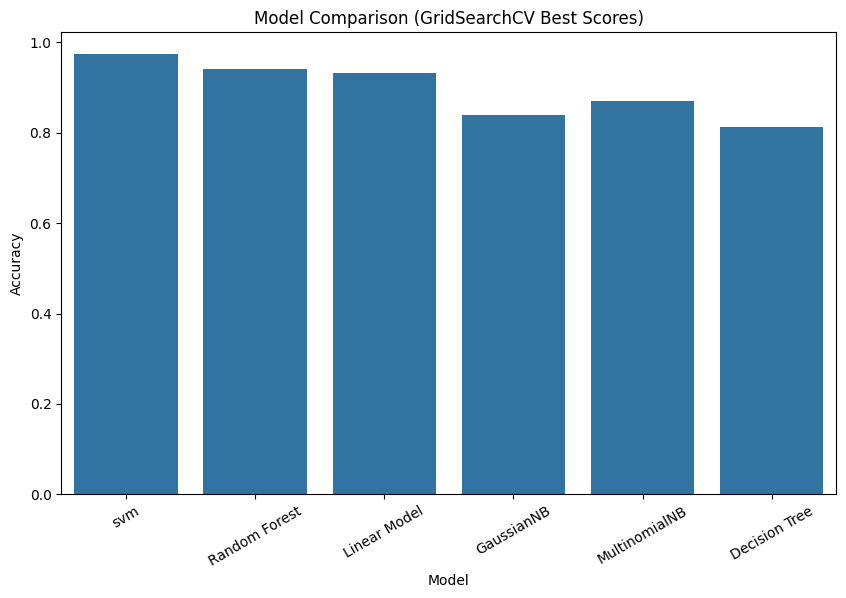

In [9]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
sns.barplot(x='model', y='best_score', data=df)

plt.title("Model Comparison (GridSearchCV Best Scores)")
plt.xlabel("Model")
plt.ylabel("Accuracy")
plt.xticks(rotation=30)
plt.show()

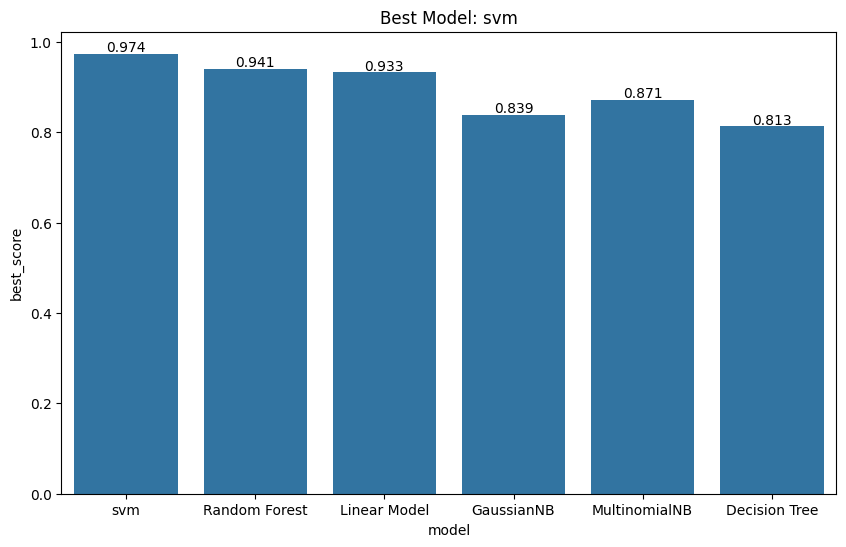

In [10]:
best_model = df.loc[df['best_score'].idxmax()]

plt.figure(figsize=(10,6))
ax = sns.barplot(x='model', y='best_score', data=df)

for i, v in enumerate(df['best_score']):
    ax.text(i, v + 0.005, f"{v:.3f}", ha='center')

plt.title(f"Best Model: {best_model['model']}")
plt.show()

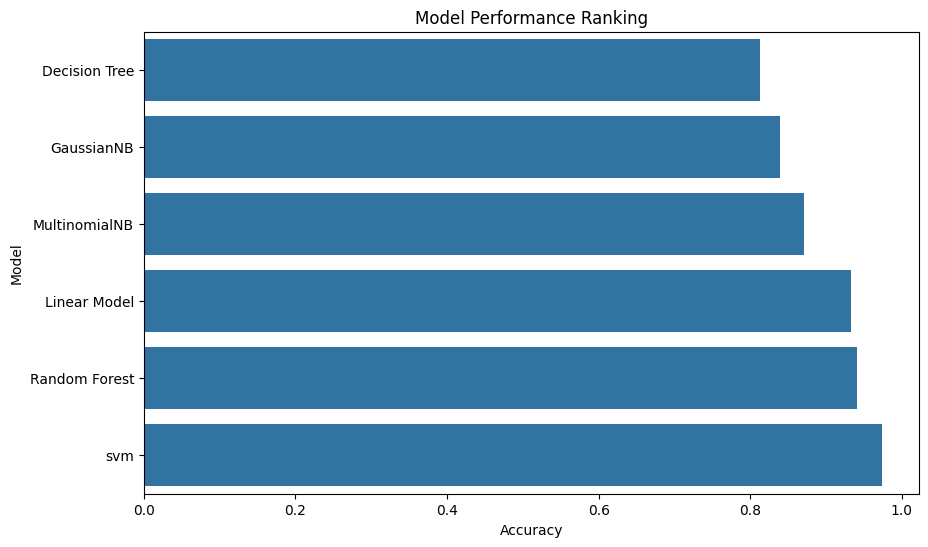

In [11]:
results_sorted = df.sort_values(by='best_score', ascending=True)

plt.figure(figsize=(10,6))
sns.barplot(x='best_score', y='model', data=results_sorted)

plt.title("Model Performance Ranking")
plt.xlabel("Accuracy")
plt.ylabel("Model")
plt.show()

In [14]:
df.style.background_gradient(cmap='viridis')

,model,best_score,best_params
0,svm,0.973850,"{'C': 10, 'degree': 2, 'gamma': 'scale', 'kernel': 'rbf'}"
1,Random Forest,0.941032,"{'criterion': 'gini', 'max_depth': 10, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 100}"
2,Linear Model,0.932685,"{'C': 0.1, 'max_iter': 100, 'penalty': 'l1', 'solver': 'saga'}"
3,GaussianNB,0.838635,{'var_smoothing': 1e-06}
4,MultinomialNB,0.871464,"{'alpha': 2.0, 'fit_prior': True}"
5,Decision Tree,0.813033,"{'criterion': 'entropy', 'max_depth': 20, 'min_samples_leaf': 1, 'min_samples_split': 5, 'splitter': 'best'}"
